In [31]:
# ============================================================================
# GERAÇÃO DE DADOS SINTÉTICOS USANDO LATIN HYPERCUBE SAMPLING (LHS)
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import odeint
import sys
import os
import warnings
warnings.filterwarnings('ignore')

# Adicionar o caminho para importar o modelo de pré-tratamento
sys.path.append(os.path.abspath(os.path.join('..', '..', '..')))
from Hydrothermal_Pretreatment import simulate_hydrothermal_degradation

print("=" * 80)
print("GERAÇÃO DE DADOS SINTÉTICOS - PRÉ-TRATAMENTO HIDROTÉRMICO")
print("Latin Hypercube Sampling + Modelo de Degradação Térmica")
print("=" * 80)

GERAÇÃO DE DADOS SINTÉTICOS - PRÉ-TRATAMENTO HIDROTÉRMICO
Latin Hypercube Sampling + Modelo de Degradação Térmica


In [32]:
# ============================================================================
# 1. DEFINIÇÃO DOS PARÂMETROS DE VARIAÇÃO
# ============================================================================

print("\n1. DEFININDO RANGOS DE PARÂMETROS...")

# Definir os rangos de variação para cada parâmetro
param_ranges = {
    'temperature': (180.0, 210.0),           # °C - temperatura do pré-tratamento
    'solids_loading': (50.0, 150.0),         # g/L - carregamento de sólidos
    'cellulose_fraction': (0.30, 0.50),      # fração de celulose na biomassa
    'hemicellulose_fraction': (0.15, 0.30),  # fração de hemicelulose na biomassa
}

# Tempos específicos para simulação (baseados nos dados experimentais)
time_points = np.array([0, 5, 10, 15, 20, 30, 40])  # minutos

print(f"✓ Temperature: {param_ranges['temperature'][0]:.1f} - {param_ranges['temperature'][1]:.1f} °C")
print(f"✓ Solids Loading: {param_ranges['solids_loading'][0]:.1f} - {param_ranges['solids_loading'][1]:.1f} g/L")
print(f"✓ Celulose: {param_ranges['cellulose_fraction'][0]*100:.0f}% - {param_ranges['cellulose_fraction'][1]*100:.0f}%")
print(f"✓ Hemicelulose: {param_ranges['hemicellulose_fraction'][0]*100:.0f}% - {param_ranges['hemicellulose_fraction'][1]*100:.0f}%")
print(f"✓ Lignina: calculada automaticamente (20-40%)")
print(f"✓ Tempos de simulação: {len(time_points)} pontos - {time_points}")

# Número de combinações únicas de condições para gerar
n_conditions = 200  # Isso gerará 200 × 7 tempos = 1400 amostras no total

print(f"\n📊 ESTRATÉGIA DE AMOSTRAGEM:")
print(f"   • {n_conditions} combinações únicas de condições (LHS)")
print(f"   • {len(time_points)} tempos por condição")
print(f"   • Total de amostras: {n_conditions * len(time_points)}")
print(f"   • Lignina restrita a 20-40% através de amostragem condicionada")


1. DEFININDO RANGOS DE PARÂMETROS...
✓ Temperature: 180.0 - 210.0 °C
✓ Solids Loading: 50.0 - 150.0 g/L
✓ Celulose: 30% - 50%
✓ Hemicelulose: 15% - 30%
✓ Lignina: calculada automaticamente (20-40%)
✓ Tempos de simulação: 7 pontos - [ 0  5 10 15 20 30 40]

📊 ESTRATÉGIA DE AMOSTRAGEM:
   • 200 combinações únicas de condições (LHS)
   • 7 tempos por condição
   • Total de amostras: 1400
   • Lignina restrita a 20-40% através de amostragem condicionada


In [33]:
# ============================================================================
# 2. FUNÇÃO PARA GERAR AMOSTRAS LHS COM RESTRIÇÕES
# ============================================================================

from scipy.stats import qmc

def generate_lhs_samples_with_constraints(n_samples, param_ranges, lignin_range=(0.20, 0.40)):
    """
    Gera amostras usando Latin Hypercube Sampling com restrições de lignina
    
    Parameters:
    -----------
    n_samples : int
        Número de amostras a gerar
    param_ranges : dict
        Dicionário com os rangos de cada parâmetro
    lignin_range : tuple
        Range permitido para fração de lignina (min, max)
    
    Returns:
    --------
    samples_df : pandas.DataFrame
        DataFrame com as amostras geradas
    """
    
    print(f"\n2. GERANDO {n_samples} AMOSTRAS LHS COM RESTRIÇÕES...")
    
    # Inicializar o sampler LHS
    sampler = qmc.LatinHypercube(d=4, seed=42)  # 4 dimensões
    
    valid_samples = []
    attempts = 0
    max_attempts = n_samples * 10  # Máximo de tentativas
    
    while len(valid_samples) < n_samples and attempts < max_attempts:
        # Gerar batch de amostras
        batch_size = min(100, n_samples - len(valid_samples))
        sample_batch = sampler.random(n=batch_size)
        
        for sample in sample_batch:
            attempts += 1
            
            # Mapear amostras [0,1] para os rangos reais
            temperature = param_ranges['temperature'][0] + sample[0] * \
                         (param_ranges['temperature'][1] - param_ranges['temperature'][0])
            
            solids_loading = param_ranges['solids_loading'][0] + sample[1] * \
                           (param_ranges['solids_loading'][1] - param_ranges['solids_loading'][0])
            
            cellulose_fraction = param_ranges['cellulose_fraction'][0] + sample[2] * \
                               (param_ranges['cellulose_fraction'][1] - param_ranges['cellulose_fraction'][0])
            
            hemicellulose_fraction = param_ranges['hemicellulose_fraction'][0] + sample[3] * \
                                   (param_ranges['hemicellulose_fraction'][1] - param_ranges['hemicellulose_fraction'][0])
            
            # Calcular lignina
            lignin_fraction = 1.0 - cellulose_fraction - hemicellulose_fraction
            
            # Verificar se a lignina está dentro do range permitido
            if lignin_range[0] <= lignin_fraction <= lignin_range[1]:
                valid_samples.append({
                    'temperature': temperature,
                    'solids_loading': solids_loading,
                    'cellulose_fraction': cellulose_fraction,
                    'hemicellulose_fraction': hemicellulose_fraction,
                    'lignin_fraction': lignin_fraction
                })
                
            if len(valid_samples) >= n_samples:
                break
    
    if len(valid_samples) < n_samples:
        print(f"⚠️  Aviso: Apenas {len(valid_samples)} amostras válidas encontradas em {attempts} tentativas")
    
    # Converter para DataFrame
    samples_df = pd.DataFrame(valid_samples)
    
    print(f"✓ {len(samples_df)} amostras geradas com sucesso")
    print(f"✓ Temperatura varia de {samples_df['temperature'].min():.1f}°C a {samples_df['temperature'].max():.1f}°C")
    print(f"✓ Lignina varia de {samples_df['lignin_fraction'].min():.3f} a {samples_df['lignin_fraction'].max():.3f}")
    
    return samples_df

# Gerar as amostras
conditions_df = generate_lhs_samples_with_constraints(n_conditions, param_ranges)


2. GERANDO 200 AMOSTRAS LHS COM RESTRIÇÕES...
✓ 200 amostras geradas com sucesso
✓ Temperatura varia de 180.1°C a 210.0°C
✓ Lignina varia de 0.221 a 0.399


In [34]:
# ============================================================================
# 3. FUNÇÃO WRAPPER PARA SIMULAÇÃO DE PRÉ-TRATAMENTO
# ============================================================================

print("\n3. CONFIGURANDO SIMULAÇÃO DE PRÉ-TRATAMENTO...")

def simulate_pretreatment_condition(temperature, solid_loading, cellulose_fraction, 
                                   hemicellulose_fraction, lignin_fraction, time_points):
    """
    Simula pré-tratamento hidrotérmico para tempos específicos
    
    Parameters:
    -----------
    temperature : float
        Temperatura em °C (180-210)
    solid_loading : float
        Carga de sólidos em g/L
    cellulose_fraction : float
        Fração de celulose (0-1)
    hemicellulose_fraction : float
        Fração de hemicelulose (0-1)
    lignin_fraction : float
        Fração de lignina (0-1)
    time_points : array
        Array com os tempos desejados (minutos)
    
    Returns:
    --------
    results_df : pandas.DataFrame
        DataFrame com resultados para cada tempo (8 colunas: 6 inputs + 2 outputs)
    """
    
    # Simular até o tempo máximo
    time_final = int(np.max(time_points))
    
    # Chamar o modelo de degradação hidrotérmica
    results = simulate_hydrothermal_degradation(
        temperature=temperature,
        solid_loading=solid_loading,
        cellulose_fraction=cellulose_fraction,
        hemicellulose_fraction=hemicellulose_fraction,
        time_final=time_final
    )
    
    # Extrair concentrações nos tempos desejados
    time_array = results['time']
    cellulose_conc = results['cellulose']
    hemicellulose_conc = results['hemicellulose']
    
    # Interpolar para os tempos específicos
    cellulose_at_times = np.interp(time_points, time_array, cellulose_conc)
    hemicellulose_at_times = np.interp(time_points, time_array, hemicellulose_conc)
    
    # Criar DataFrame com resultados (apenas 2 outputs: concentrações remaining)
    results_list = []
    for i, t in enumerate(time_points):
        results_list.append({
            'Temperature [°C]': temperature,
            'Cellulose Fraction': cellulose_fraction,
            'Hemicellulose Fraction': hemicellulose_fraction,
            'Lignin Fraction': lignin_fraction,
            'Solids Loading [g/L]': solid_loading,
            'Time [min]': t,
            'Cellulose Remaining [g/L]': cellulose_at_times[i],
            'Hemicellulose Remaining [g/L]': hemicellulose_at_times[i]
        })
    
    return pd.DataFrame(results_list)

print("✓ Função de simulação configurada")
print("✓ Outputs: 2 (Cellulose Remaining, Hemicellulose Remaining)")


3. CONFIGURANDO SIMULAÇÃO DE PRÉ-TRATAMENTO...
✓ Função de simulação configurada
✓ Outputs: 2 (Cellulose Remaining, Hemicellulose Remaining)


In [35]:
# ============================================================================
# 4. GERAÇÃO DOS DADOS SINTÉTICOS
# ============================================================================

print("\n4. GERANDO DADOS SINTÉTICOS...")
print(f"📊 Simulando {len(conditions_df)} condições × {len(time_points)} tempos")

# Lista para armazenar todos os resultados
all_results = []

# Simular cada condição
for idx, condition in conditions_df.iterrows():
    
    # Mostrar progresso
    if (idx + 1) % 20 == 0 or idx == 0:
        print(f"   Processando condição {idx+1}/{len(conditions_df)}...")
    
    try:
        # Simular esta condição
        condition_results = simulate_pretreatment_condition(
            temperature=condition['temperature'],
            solid_loading=condition['solids_loading'],
            cellulose_fraction=condition['cellulose_fraction'],
            hemicellulose_fraction=condition['hemicellulose_fraction'],
            lignin_fraction=condition['lignin_fraction'],
            time_points=time_points
        )
        
        # Adicionar aos resultados
        all_results.append(condition_results)
        
    except Exception as e:
        print(f"   ⚠️  Erro na condição {idx+1}: {str(e)}")
        continue

# Concatenar todos os resultados
synthetic_data = pd.concat(all_results, ignore_index=True)

print(f"\n✓ Dados sintéticos gerados com sucesso!")
print(f"✓ Total de amostras: {len(synthetic_data)}")
print(f"✓ Condições únicas: {len(conditions_df)}")
print(f"✓ Tempos por condição: {len(time_points)}")

# Exibir primeiras linhas
print("\n📋 Primeiras amostras:")
print(synthetic_data.head(10))


4. GERANDO DADOS SINTÉTICOS...
📊 Simulando 200 condições × 7 tempos
   Processando condição 1/200...
   Processando condição 20/200...
   Processando condição 40/200...
   Processando condição 60/200...
   Processando condição 80/200...
   Processando condição 100/200...
   Processando condição 120/200...
   Processando condição 140/200...
   Processando condição 160/200...
   Processando condição 180/200...
   Processando condição 200/200...

✓ Dados sintéticos gerados com sucesso!
✓ Total de amostras: 1400
✓ Condições únicas: 200
✓ Tempos por condição: 7

📋 Primeiras amostras:
   Temperature [°C]  Cellulose Fraction  Hemicellulose Fraction  \
0        182.167813            0.380283                0.295954   
1        182.167813            0.380283                0.295954   
2        182.167813            0.380283                0.295954   
3        182.167813            0.380283                0.295954   
4        182.167813            0.380283                0.295954   
5        18


5. ANÁLISE ESTATÍSTICA DOS DADOS SINTÉTICOS...

📊 ESTATÍSTICAS GERAIS:
   • Total de amostras: 1400
   • Condições únicas: 200
   • Tempos simulados: [0, 5, 10, 15, 20, 30, 40]

🌡️  TEMPERATURA:
   • Mínima: 180.1°C
   • Máxima: 210.0°C
   • Média: 194.8°C
   • Desvio: 8.6°C

📦 CELLULOSE REMAINING:
   • Média: 33.31 g/L
   • Desvio: 13.35 g/L
   • Range: 7.26 - 71.50 g/L

📦 HEMICELLULOSE REMAINING:
   • Média: 8.30 g/L
   • Desvio: 8.87 g/L
   • Range: 0.00 - 43.23 g/L

⏰ ANÁLISE POR TEMPO (Concentração média remaining):
   • t= 0min: Cellulose=43.3 g/L, Hemicelulose=24.0 g/L
   • t= 5min: Cellulose=39.7 g/L, Hemicelulose=13.8 g/L
   • t=10min: Cellulose=36.5 g/L, Hemicelulose=8.4 g/L
   • t=15min: Cellulose=33.5 g/L, Hemicelulose=5.5 g/L
   • t=20min: Cellulose=30.9 g/L, Hemicelulose=3.7 g/L
   • t=30min: Cellulose=26.4 g/L, Hemicelulose=1.8 g/L
   • t=40min: Cellulose=22.7 g/L, Hemicelulose=1.0 g/L


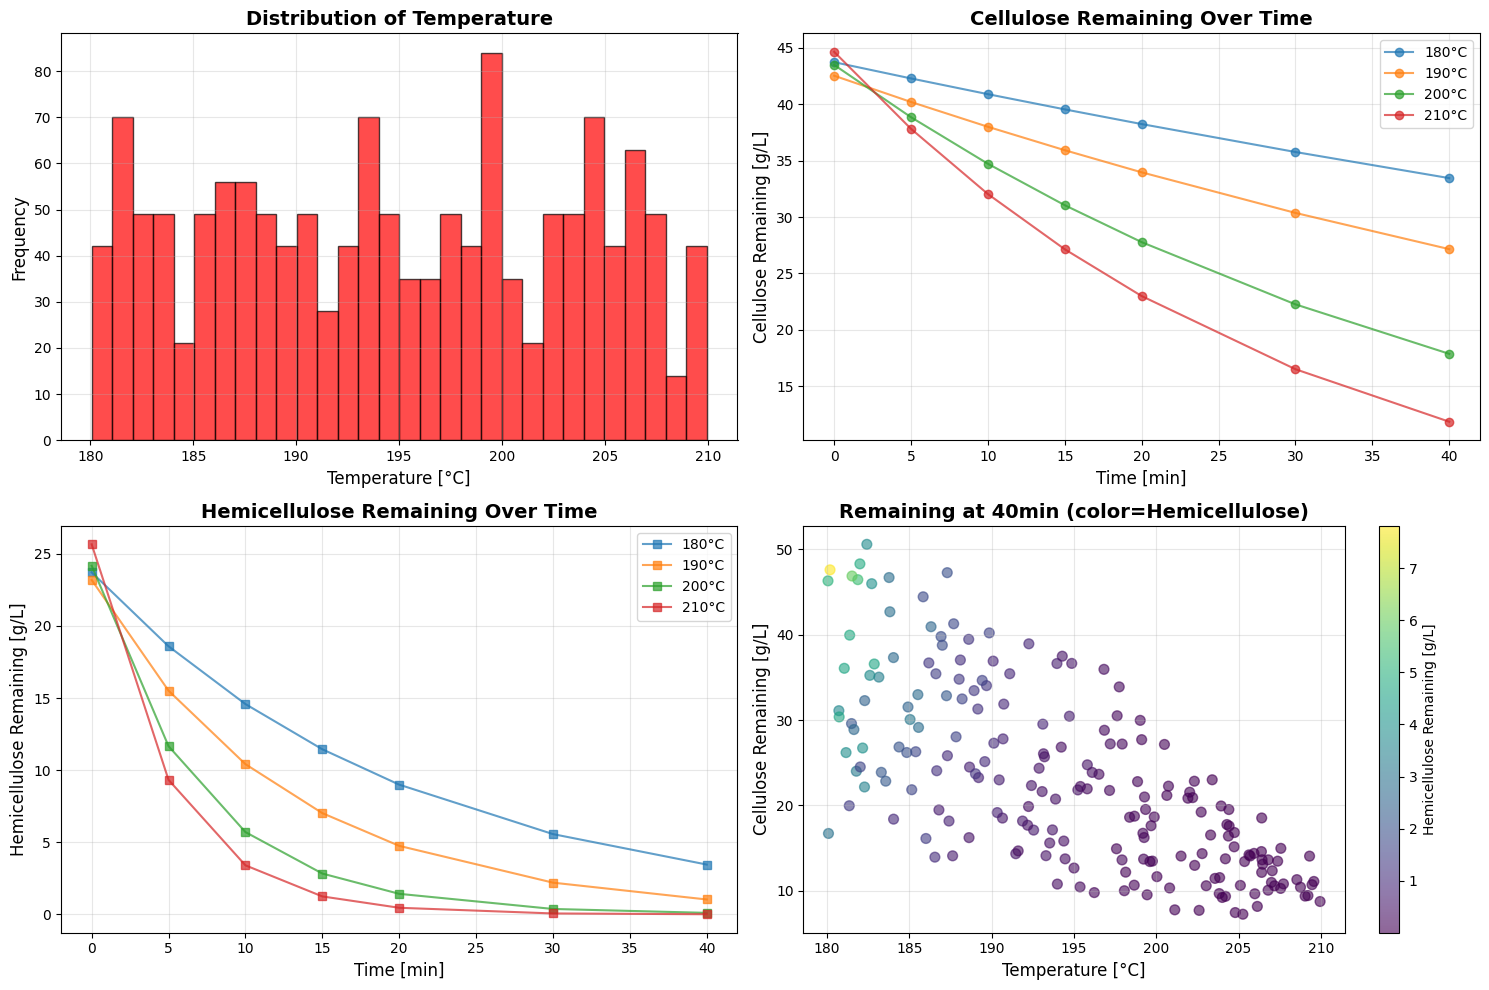

In [36]:
# ============================================================================
# 5. ANÁLISE ESTATÍSTICA DOS DADOS GERADOS
# ============================================================================

print("\n5. ANÁLISE ESTATÍSTICA DOS DADOS SINTÉTICOS...")

print(f"\n📊 ESTATÍSTICAS GERAIS:")
print(f"   • Total de amostras: {len(synthetic_data)}")
print(f"   • Condições únicas: {synthetic_data.groupby(['Temperature [°C]', 'Solids Loading [g/L]', 'Cellulose Fraction']).ngroups}")
print(f"   • Tempos simulados: {sorted(synthetic_data['Time [min]'].unique())}")

print(f"\n🌡️  TEMPERATURA:")
print(f"   • Mínima: {synthetic_data['Temperature [°C]'].min():.1f}°C")
print(f"   • Máxima: {synthetic_data['Temperature [°C]'].max():.1f}°C")
print(f"   • Média: {synthetic_data['Temperature [°C]'].mean():.1f}°C")
print(f"   • Desvio: {synthetic_data['Temperature [°C]'].std():.1f}°C")

print(f"\n📦 CELLULOSE REMAINING:")
print(f"   • Média: {synthetic_data['Cellulose Remaining [g/L]'].mean():.2f} g/L")
print(f"   • Desvio: {synthetic_data['Cellulose Remaining [g/L]'].std():.2f} g/L")
print(f"   • Range: {synthetic_data['Cellulose Remaining [g/L]'].min():.2f} - {synthetic_data['Cellulose Remaining [g/L]'].max():.2f} g/L")

print(f"\n📦 HEMICELLULOSE REMAINING:")
print(f"   • Média: {synthetic_data['Hemicellulose Remaining [g/L]'].mean():.2f} g/L")
print(f"   • Desvio: {synthetic_data['Hemicellulose Remaining [g/L]'].std():.2f} g/L")
print(f"   • Range: {synthetic_data['Hemicellulose Remaining [g/L]'].min():.2f} - {synthetic_data['Hemicellulose Remaining [g/L]'].max():.2f} g/L")

# Análise por tempo
print(f"\n⏰ ANÁLISE POR TEMPO (Concentração média remaining):")
for t in sorted(time_points):
    data_t = synthetic_data[synthetic_data['Time [min]'] == t]
    cell_mean = data_t['Cellulose Remaining [g/L]'].mean()
    hemi_mean = data_t['Hemicellulose Remaining [g/L]'].mean()
    print(f"   • t={t:2.0f}min: Cellulose={cell_mean:.1f} g/L, Hemicelulose={hemi_mean:.1f} g/L")

# Visualização
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Distribuição de temperatura
axes[0, 0].hist(synthetic_data['Temperature [°C]'], bins=30, color='red', alpha=0.7, edgecolor='black')
axes[0, 0].set_xlabel('Temperature [°C]', fontsize=12)
axes[0, 0].set_ylabel('Frequency', fontsize=12)
axes[0, 0].set_title('Distribution of Temperature', fontsize=14, fontweight='bold')
axes[0, 0].grid(alpha=0.3)

# Plot 2: Celulose remaining ao longo do tempo
for temp_group in [180, 190, 200, 210]:
    data_temp = synthetic_data[abs(synthetic_data['Temperature [°C]'] - temp_group) < 5]
    if len(data_temp) > 0:
        time_grouped = data_temp.groupby('Time [min]')['Cellulose Remaining [g/L]'].mean()
        axes[0, 1].plot(time_grouped.index, time_grouped.values, 'o-', label=f'{temp_group}°C', alpha=0.7)
axes[0, 1].set_xlabel('Time [min]', fontsize=12)
axes[0, 1].set_ylabel('Cellulose Remaining [g/L]', fontsize=12)
axes[0, 1].set_title('Cellulose Remaining Over Time', fontsize=14, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Plot 3: Hemicelulose remaining ao longo do tempo
for temp_group in [180, 190, 200, 210]:
    data_temp = synthetic_data[abs(synthetic_data['Temperature [°C]'] - temp_group) < 5]
    if len(data_temp) > 0:
        time_grouped = data_temp.groupby('Time [min]')['Hemicellulose Remaining [g/L]'].mean()
        axes[1, 0].plot(time_grouped.index, time_grouped.values, 's-', label=f'{temp_group}°C', alpha=0.7)
axes[1, 0].set_xlabel('Time [min]', fontsize=12)
axes[1, 0].set_ylabel('Hemicellulose Remaining [g/L]', fontsize=12)
axes[1, 0].set_title('Hemicellulose Remaining Over Time', fontsize=14, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Plot 4: Scatter de temperatura vs concentração final
final_time_data = synthetic_data[synthetic_data['Time [min]'] == time_points[-1]]
scatter = axes[1, 1].scatter(final_time_data['Temperature [°C]'], 
                            final_time_data['Cellulose Remaining [g/L]'], 
                            c=final_time_data['Hemicellulose Remaining [g/L]'],
                            cmap='viridis', alpha=0.6, s=50)
axes[1, 1].set_xlabel('Temperature [°C]', fontsize=12)
axes[1, 1].set_ylabel('Cellulose Remaining [g/L]', fontsize=12)
axes[1, 1].set_title(f'Remaining at {time_points[-1]}min (color=Hemicellulose)', fontsize=14, fontweight='bold')
plt.colorbar(scatter, ax=axes[1, 1], label='Hemicellulose Remaining [g/L]')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


6. VERIFICAÇÃO DA QUALIDADE DA AMOSTRAGEM LHS...


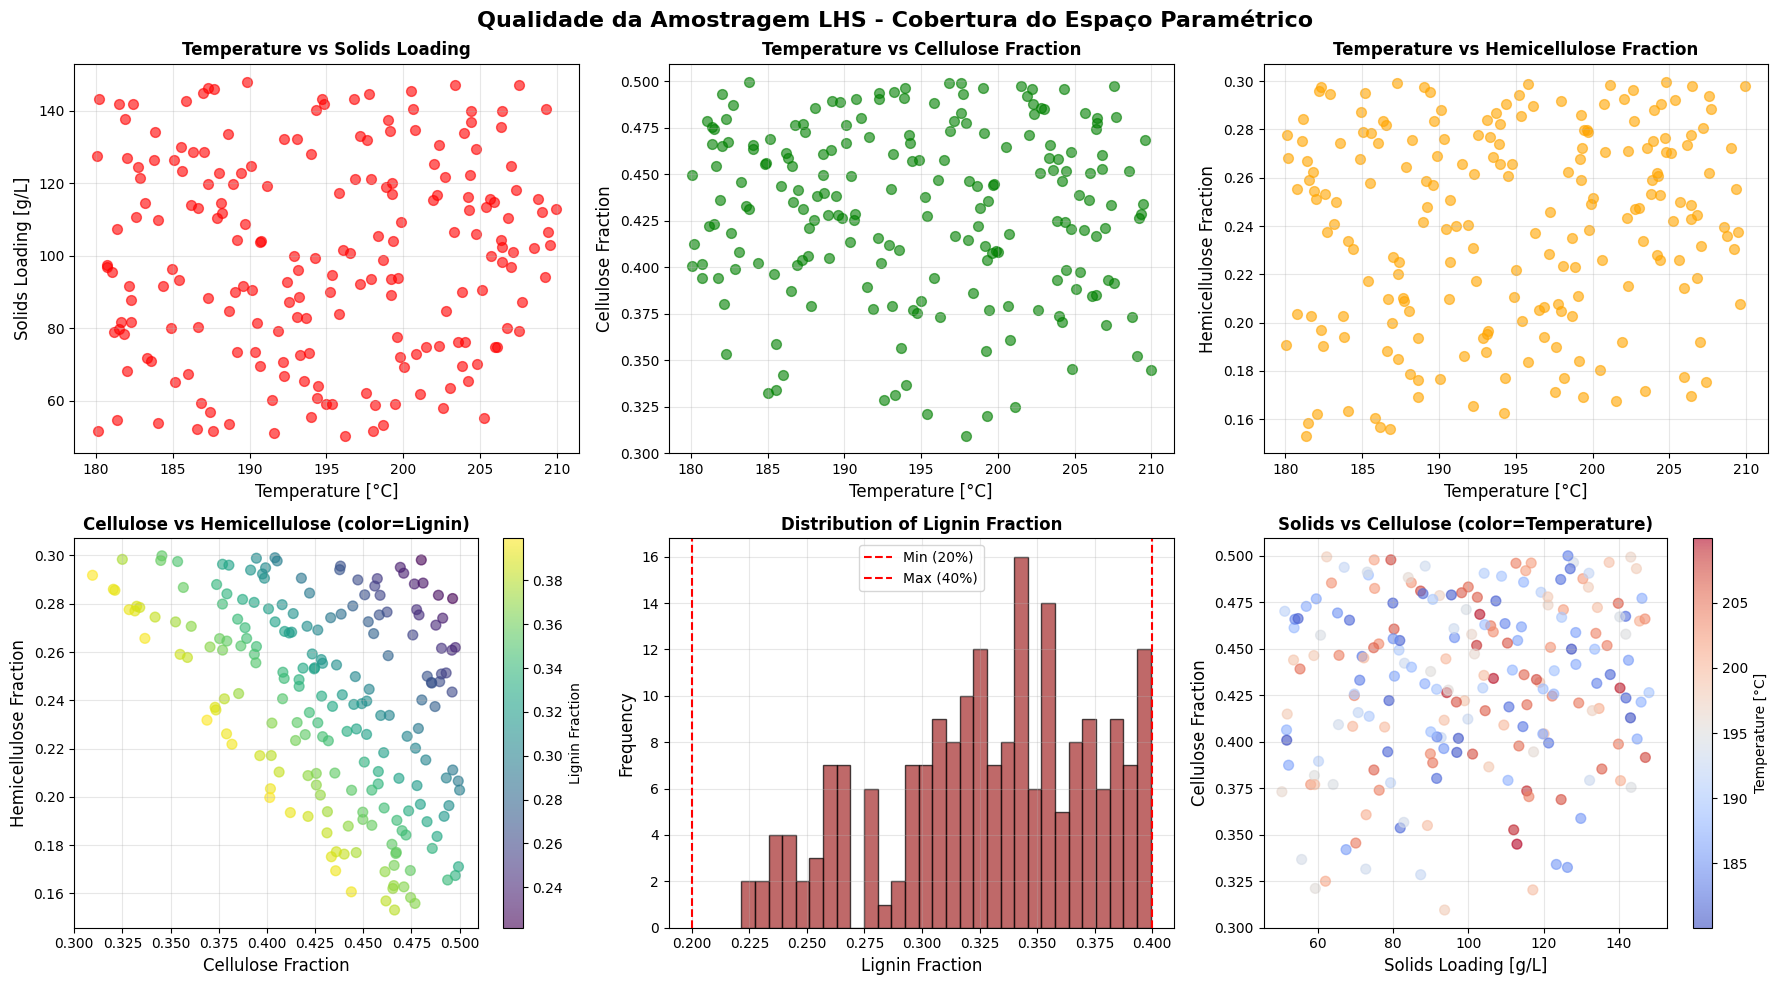


✓ Análise de qualidade concluída


In [37]:
# ============================================================================
# 6. QUALIDADE DA AMOSTRAGEM LHS
# ============================================================================

print("\n6. VERIFICAÇÃO DA QUALIDADE DA AMOSTRAGEM LHS...")

# Extrair apenas as condições únicas (ignorar tempo)
unique_conditions = conditions_df.copy()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Qualidade da Amostragem LHS - Cobertura do Espaço Paramétrico', 
             fontsize=16, fontweight='bold')

# Plot 1: Temperature vs Solids Loading
axes[0, 0].scatter(unique_conditions['temperature'], unique_conditions['solids_loading'], 
                  alpha=0.6, s=50, color='red')
axes[0, 0].set_xlabel('Temperature [°C]', fontsize=12)
axes[0, 0].set_ylabel('Solids Loading [g/L]', fontsize=12)
axes[0, 0].set_title('Temperature vs Solids Loading', fontsize=12, fontweight='bold')
axes[0, 0].grid(alpha=0.3)

# Plot 2: Temperature vs Cellulose Fraction
axes[0, 1].scatter(unique_conditions['temperature'], unique_conditions['cellulose_fraction'], 
                  alpha=0.6, s=50, color='green')
axes[0, 1].set_xlabel('Temperature [°C]', fontsize=12)
axes[0, 1].set_ylabel('Cellulose Fraction', fontsize=12)
axes[0, 1].set_title('Temperature vs Cellulose Fraction', fontsize=12, fontweight='bold')
axes[0, 1].grid(alpha=0.3)

# Plot 3: Temperature vs Hemicellulose Fraction
axes[0, 2].scatter(unique_conditions['temperature'], unique_conditions['hemicellulose_fraction'], 
                  alpha=0.6, s=50, color='orange')
axes[0, 2].set_xlabel('Temperature [°C]', fontsize=12)
axes[0, 2].set_ylabel('Hemicellulose Fraction', fontsize=12)
axes[0, 2].set_title('Temperature vs Hemicellulose Fraction', fontsize=12, fontweight='bold')
axes[0, 2].grid(alpha=0.3)

# Plot 4: Cellulose vs Hemicellulose
scatter = axes[1, 0].scatter(unique_conditions['cellulose_fraction'], 
                            unique_conditions['hemicellulose_fraction'],
                            c=unique_conditions['lignin_fraction'], 
                            cmap='viridis', alpha=0.6, s=50)
axes[1, 0].set_xlabel('Cellulose Fraction', fontsize=12)
axes[1, 0].set_ylabel('Hemicellulose Fraction', fontsize=12)
axes[1, 0].set_title('Cellulose vs Hemicellulose (color=Lignin)', fontsize=12, fontweight='bold')
plt.colorbar(scatter, ax=axes[1, 0], label='Lignin Fraction')
axes[1, 0].grid(alpha=0.3)

# Plot 5: Distribuição de Lignina
axes[1, 1].hist(unique_conditions['lignin_fraction'], bins=30, color='brown', 
               alpha=0.7, edgecolor='black')
axes[1, 1].set_xlabel('Lignin Fraction', fontsize=12)
axes[1, 1].set_ylabel('Frequency', fontsize=12)
axes[1, 1].set_title('Distribution of Lignin Fraction', fontsize=12, fontweight='bold')
axes[1, 1].axvline(x=0.20, color='red', linestyle='--', label='Min (20%)')
axes[1, 1].axvline(x=0.40, color='red', linestyle='--', label='Max (40%)')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

# Plot 6: Solids Loading vs Cellulose
scatter = axes[1, 2].scatter(unique_conditions['solids_loading'], 
                            unique_conditions['cellulose_fraction'],
                            c=unique_conditions['temperature'], 
                            cmap='coolwarm', alpha=0.6, s=50)
axes[1, 2].set_xlabel('Solids Loading [g/L]', fontsize=12)
axes[1, 2].set_ylabel('Cellulose Fraction', fontsize=12)
axes[1, 2].set_title('Solids vs Cellulose (color=Temperature)', fontsize=12, fontweight='bold')
plt.colorbar(scatter, ax=axes[1, 2], label='Temperature [°C]')
axes[1, 2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Análise de qualidade concluída")

In [38]:
# ============================================================================
# 7. EXPORTAÇÃO DOS DADOS SINTÉTICOS
# ============================================================================

print("\n7. EXPORTANDO DADOS...")

# Salvar em CSV com colunas padronizadas (8 colunas: 6 inputs + 2 outputs)
output_filename = 'synthetic_pretreatment_data_LHS.csv'
synthetic_data.to_csv(output_filename, index=False, float_format='%.4f')

print(f"✓ Dados salvos em: {output_filename}")
print(f"✓ Total de amostras: {len(synthetic_data)}")
print(f"✓ Condições únicas: {len(conditions_df)}")
print(f"✓ Colunas: {len(synthetic_data.columns)} (6 inputs + 2 outputs)")

# Mostrar primeiras linhas
print(f"\n📋 PRIMEIRAS 10 LINHAS DOS DADOS FINAIS:")
print(synthetic_data.head(10).to_string(index=False))

print(f"\n📋 ÚLTIMAS 5 LINHAS DOS DADOS FINAIS:")
print(synthetic_data.tail(5).to_string(index=False))

# ============================================================================
# RESUMO FINAL
# ============================================================================

print("\n" + "=" * 80)
print("GERAÇÃO DE DADOS SINTÉTICOS DE PRÉ-TRATAMENTO CONCLUÍDA COM SUCESSO! ✓")
print("=" * 80)
print(f"\n📊 RESUMO:")
print(f"   • Método: Latin Hypercube Sampling (LHS)")
print(f"   • Modelo: Degradação Hidrotérmica com Temperatura Contínua")
print(f"   • Total de amostras: {len(synthetic_data)}")
print(f"   • Condições únicas: {len(conditions_df)}")
print(f"   • Tempos por condição: {len(time_points)}")
print(f"   • Arquivo de saída: {output_filename}")
print(f"\n📥 INPUTS (6 features):")
print(f"   • Temperature [°C]: {synthetic_data['Temperature [°C]'].min():.1f} - {synthetic_data['Temperature [°C]'].max():.1f}")
print(f"   • Cellulose Fraction: {synthetic_data['Cellulose Fraction'].min():.2f} - {synthetic_data['Cellulose Fraction'].max():.2f}")
print(f"   • Hemicellulose Fraction: {synthetic_data['Hemicellulose Fraction'].min():.2f} - {synthetic_data['Hemicellulose Fraction'].max():.2f}")
print(f"   • Lignin Fraction: {synthetic_data['Lignin Fraction'].min():.2f} - {synthetic_data['Lignin Fraction'].max():.2f}")
print(f"   • Solids Loading [g/L]: {synthetic_data['Solids Loading [g/L]'].min():.1f} - {synthetic_data['Solids Loading [g/L]'].max():.1f}")
print(f"   • Time [min]: {synthetic_data['Time [min]'].min():.0f} - {synthetic_data['Time [min]'].max():.0f}")
print(f"\n📤 OUTPUTS (2 features):")
print(f"   • Cellulose Remaining [g/L]: {synthetic_data['Cellulose Remaining [g/L]'].min():.2f} - {synthetic_data['Cellulose Remaining [g/L]'].max():.2f}")
print(f"   • Hemicellulose Remaining [g/L]: {synthetic_data['Hemicellulose Remaining [g/L]'].min():.2f} - {synthetic_data['Hemicellulose Remaining [g/L]'].max():.2f}")
print(f"\n✅ Próximo passo: Treinar modelo ANN com estes dados!")
print(f"💡 Nota: Degradação % pode ser calculada posteriormente como (C0-C_pred)/C0*100")
print("=" * 80)


7. EXPORTANDO DADOS...
✓ Dados salvos em: synthetic_pretreatment_data_LHS.csv
✓ Total de amostras: 1400
✓ Condições únicas: 200
✓ Colunas: 8 (6 inputs + 2 outputs)

📋 PRIMEIRAS 10 LINHAS DOS DADOS FINAIS:
 Temperature [°C]  Cellulose Fraction  Hemicellulose Fraction  Lignin Fraction  Solids Loading [g/L]  Time [min]  Cellulose Remaining [g/L]  Hemicellulose Remaining [g/L]
       182.167813            0.380283                0.295954         0.323763             91.561122           0                  34.819120                      27.097875
       182.167813            0.380283                0.295954         0.323763             91.561122           5                  33.686294                      21.291034
       182.167813            0.380283                0.295954         0.323763             91.561122          10                  32.590324                      16.728524
       182.167813            0.380283                0.295954         0.323763             91.561122          


8. GERANDO VISUALIZAÇÕES DETALHADAS...


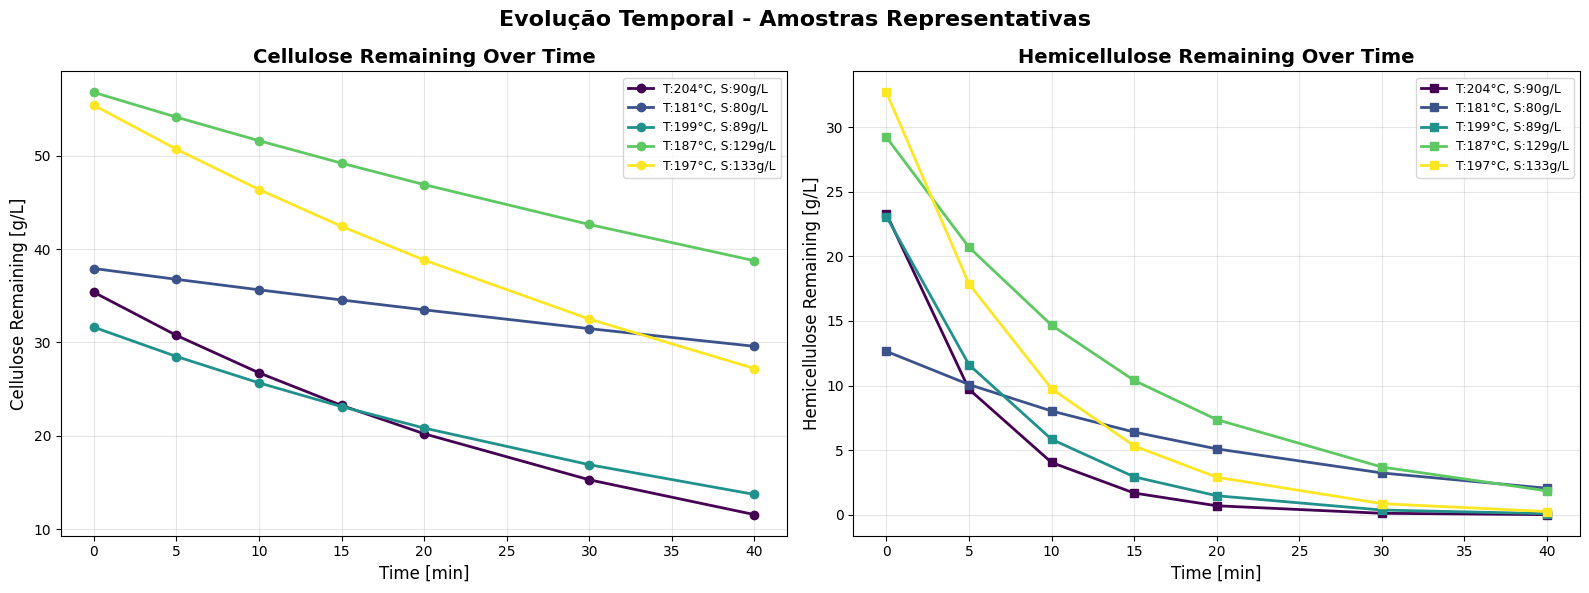

✓ Visualizações adicionais geradas


In [39]:
# ============================================================================
# 8. VISUALIZAÇÕES ADICIONAIS - ANÁLISE DETALHADA
# ============================================================================

print("\n8. GERANDO VISUALIZAÇÕES DETALHADAS...")

# ============================================================================
# GRÁFICO 1: EVOLUÇÃO TEMPORAL DE AMOSTRAS REPRESENTATIVAS
# ============================================================================

fig1, axes1 = plt.subplots(1, 2, figsize=(16, 6))
fig1.suptitle('Evolução Temporal - Amostras Representativas', fontsize=16, fontweight='bold')

# Selecionar 5 condições aleatórias
np.random.seed(42)
sample_indices = np.random.choice(len(conditions_df), 5, replace=False)
sample_conditions = conditions_df.iloc[sample_indices]
colors = plt.cm.viridis(np.linspace(0, 1, 5))

# 1.1 Celulose remanescente ao longo do tempo
for i, (idx, condition) in enumerate(sample_conditions.iterrows()):
    condition_data = synthetic_data[
        (abs(synthetic_data['Temperature [°C]'] - condition['temperature']) < 0.1) &
        (abs(synthetic_data['Solids Loading [g/L]'] - condition['solids_loading']) < 0.1) &
        (abs(synthetic_data['Cellulose Fraction'] - condition['cellulose_fraction']) < 0.01)
    ].sort_values('Time [min]')
    
    axes1[0].plot(condition_data['Time [min]'], condition_data['Cellulose Remaining [g/L]'], 
                   marker='o', color=colors[i], linewidth=2, markersize=6,
                   label=f'T:{condition["temperature"]:.0f}°C, S:{condition["solids_loading"]:.0f}g/L')

axes1[0].set_xlabel('Time [min]', fontsize=12)
axes1[0].set_ylabel('Cellulose Remaining [g/L]', fontsize=12)
axes1[0].set_title('Cellulose Remaining Over Time', fontsize=14, fontweight='bold')
axes1[0].grid(True, alpha=0.3)
axes1[0].legend(fontsize=9)

# 1.2 Hemicelulose remanescente ao longo do tempo
for i, (idx, condition) in enumerate(sample_conditions.iterrows()):
    condition_data = synthetic_data[
        (abs(synthetic_data['Temperature [°C]'] - condition['temperature']) < 0.1) &
        (abs(synthetic_data['Solids Loading [g/L]'] - condition['solids_loading']) < 0.1) &
        (abs(synthetic_data['Cellulose Fraction'] - condition['cellulose_fraction']) < 0.01)
    ].sort_values('Time [min]')
    
    axes1[1].plot(condition_data['Time [min]'], condition_data['Hemicellulose Remaining [g/L]'], 
                   marker='s', color=colors[i], linewidth=2, markersize=6,
                   label=f'T:{condition["temperature"]:.0f}°C, S:{condition["solids_loading"]:.0f}g/L')

axes1[1].set_xlabel('Time [min]', fontsize=12)
axes1[1].set_ylabel('Hemicellulose Remaining [g/L]', fontsize=12)
axes1[1].set_title('Hemicellulose Remaining Over Time', fontsize=14, fontweight='bold')
axes1[1].grid(True, alpha=0.3)
axes1[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print("✓ Visualizações adicionais geradas")


9. GERANDO ANÁLISE DE CORRELAÇÕES...


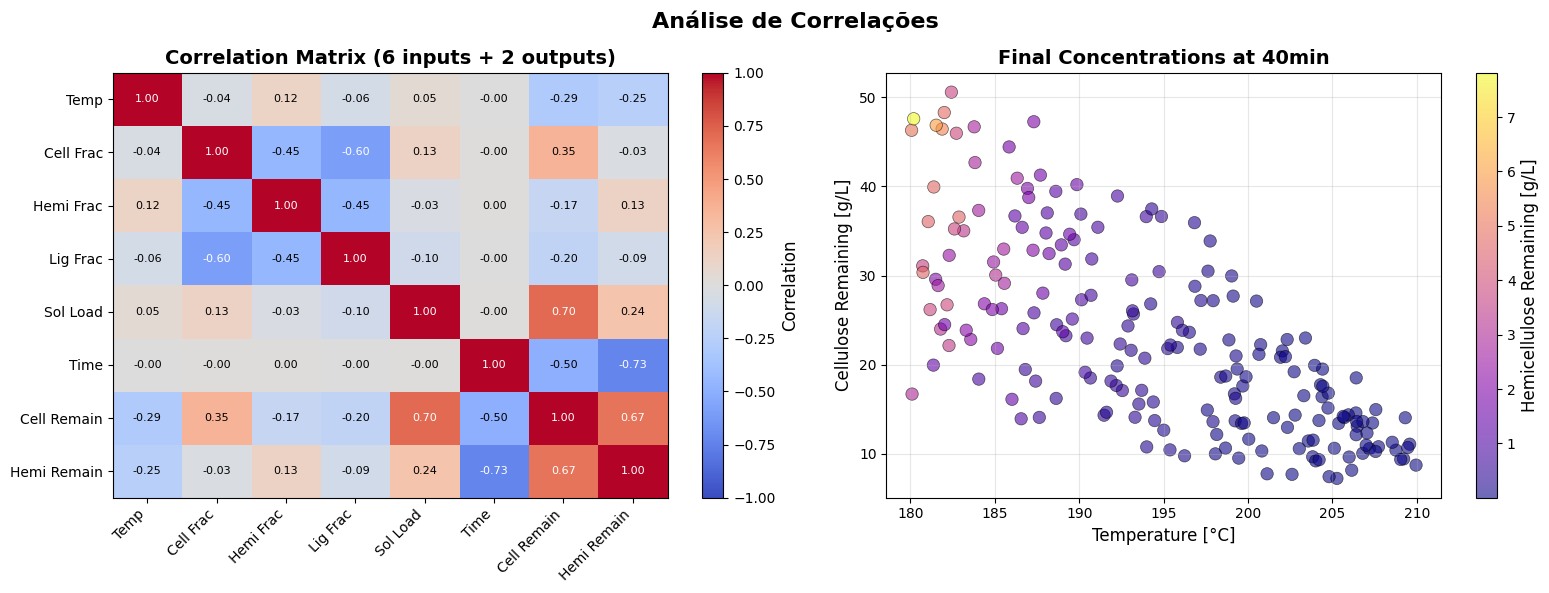

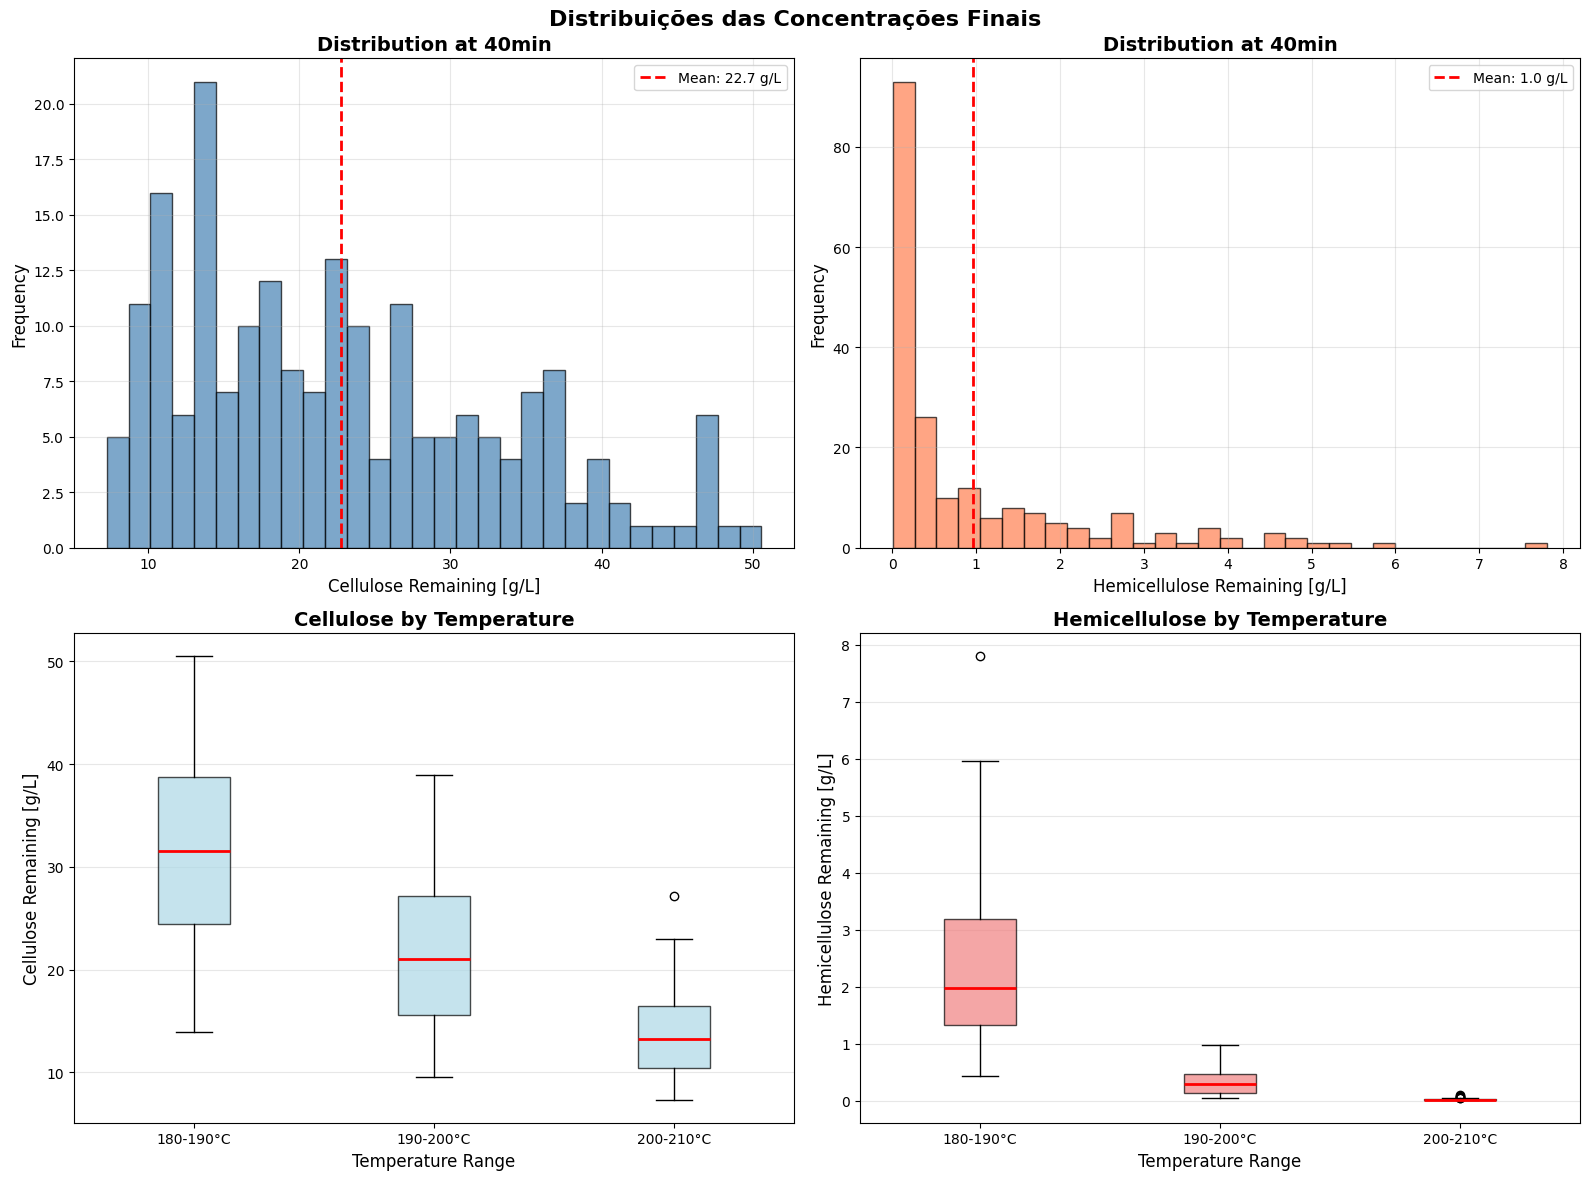

✓ Análise de correlações concluída

FIM DA GERAÇÃO E ANÁLISE DE DADOS SINTÉTICOS


In [40]:
# ============================================================================
# 9. ANÁLISE DE CORRELAÇÕES E HEATMAPS
# ============================================================================

print("\n9. GERANDO ANÁLISE DE CORRELAÇÕES...")

fig2, axes2 = plt.subplots(1, 2, figsize=(16, 6))
fig2.suptitle('Análise de Correlações', fontsize=16, fontweight='bold')

# 2.1 Heatmap de Correlação (8 colunas: 6 inputs + 2 outputs)
correlation_cols = ['Temperature [°C]', 'Cellulose Fraction', 'Hemicellulose Fraction', 
                   'Lignin Fraction', 'Solids Loading [g/L]', 'Time [min]',
                   'Cellulose Remaining [g/L]', 'Hemicellulose Remaining [g/L]']

correlation_data = synthetic_data[correlation_cols].corr()

im1 = axes2[0].imshow(correlation_data, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
axes2[0].set_xticks(range(len(correlation_data.columns)))
axes2[0].set_yticks(range(len(correlation_data.columns)))

# Nomes abreviados para exibição
short_names = ['Temp', 'Cell Frac', 'Hemi Frac', 'Lig Frac', 'Sol Load', 'Time',
              'Cell Remain', 'Hemi Remain']

axes2[0].set_xticklabels(short_names, rotation=45, ha='right', fontsize=10)
axes2[0].set_yticklabels(short_names, fontsize=10)
axes2[0].set_title('Correlation Matrix (6 inputs + 2 outputs)', fontsize=14, fontweight='bold')

# Adicionar valores na matriz
for i in range(len(correlation_data)):
    for j in range(len(correlation_data.columns)):
        text = axes2[0].text(j, i, f'{correlation_data.iloc[i, j]:.2f}', 
                           ha="center", va="center", 
                           color="white" if abs(correlation_data.iloc[i, j]) > 0.5 else "black", 
                           fontsize=8)

cbar1 = plt.colorbar(im1, ax=axes2[0])
cbar1.set_label('Correlation', fontsize=12)

# 2.2 Scatter plot: Temperatura vs Concentração Final
final_data = synthetic_data[synthetic_data['Time [min]'] == time_points[-1]]

scatter = axes2[1].scatter(final_data['Temperature [°C]'], 
                          final_data['Cellulose Remaining [g/L]'], 
                          c=final_data['Hemicellulose Remaining [g/L]'],
                          s=80, alpha=0.6, cmap='plasma', edgecolors='black', linewidth=0.5)

axes2[1].set_xlabel('Temperature [°C]', fontsize=12)
axes2[1].set_ylabel('Cellulose Remaining [g/L]', fontsize=12)
axes2[1].set_title(f'Final Concentrations at {time_points[-1]}min', fontsize=14, fontweight='bold')
axes2[1].grid(True, alpha=0.3)

cbar2 = plt.colorbar(scatter, ax=axes2[1])
cbar2.set_label('Hemicellulose Remaining [g/L]', fontsize=12)

plt.tight_layout()
plt.show()

# ============================================================================
# GRÁFICO 3: DISTRIBUIÇÕES FINAIS
# ============================================================================

fig3, axes3 = plt.subplots(2, 2, figsize=(16, 12))
fig3.suptitle('Distribuições das Concentrações Finais', fontsize=16, fontweight='bold')

final_time_data = synthetic_data[synthetic_data['Time [min]'] == time_points[-1]]

# 3.1 Histograma Cellulose Remaining
axes3[0,0].hist(final_time_data['Cellulose Remaining [g/L]'], bins=30, color='steelblue', 
               alpha=0.7, edgecolor='black')
axes3[0,0].set_xlabel('Cellulose Remaining [g/L]', fontsize=12)
axes3[0,0].set_ylabel('Frequency', fontsize=12)
axes3[0,0].set_title(f'Distribution at {time_points[-1]}min', fontsize=14, fontweight='bold')
axes3[0,0].axvline(final_time_data['Cellulose Remaining [g/L]'].mean(), color='red', 
                  linestyle='--', linewidth=2, label=f'Mean: {final_time_data["Cellulose Remaining [g/L]"].mean():.1f} g/L')
axes3[0,0].legend()
axes3[0,0].grid(alpha=0.3)

# 3.2 Histograma Hemicellulose Remaining
axes3[0,1].hist(final_time_data['Hemicellulose Remaining [g/L]'], bins=30, color='coral', 
               alpha=0.7, edgecolor='black')
axes3[0,1].set_xlabel('Hemicellulose Remaining [g/L]', fontsize=12)
axes3[0,1].set_ylabel('Frequency', fontsize=12)
axes3[0,1].set_title(f'Distribution at {time_points[-1]}min', fontsize=14, fontweight='bold')
axes3[0,1].axvline(final_time_data['Hemicellulose Remaining [g/L]'].mean(), color='red', 
                  linestyle='--', linewidth=2, label=f'Mean: {final_time_data["Hemicellulose Remaining [g/L]"].mean():.1f} g/L')
axes3[0,1].legend()
axes3[0,1].grid(alpha=0.3)

# 3.3 Box plot por faixas de temperatura - Cellulose
temp_bins = [180, 190, 200, 210]
temp_labels = ['180-190°C', '190-200°C', '200-210°C']
final_time_data['Temp_Bin'] = pd.cut(final_time_data['Temperature [°C]'], bins=temp_bins, labels=temp_labels)

cellulose_by_temp = [final_time_data[final_time_data['Temp_Bin'] == label]['Cellulose Remaining [g/L]'].values 
                    for label in temp_labels]
axes3[1,0].boxplot(cellulose_by_temp, labels=temp_labels, patch_artist=True,
                  boxprops=dict(facecolor='lightblue', alpha=0.7),
                  medianprops=dict(color='red', linewidth=2))
axes3[1,0].set_xlabel('Temperature Range', fontsize=12)
axes3[1,0].set_ylabel('Cellulose Remaining [g/L]', fontsize=12)
axes3[1,0].set_title('Cellulose by Temperature', fontsize=14, fontweight='bold')
axes3[1,0].grid(alpha=0.3, axis='y')

# 3.4 Box plot hemicelulose por temperatura
hemicellulose_by_temp = [final_time_data[final_time_data['Temp_Bin'] == label]['Hemicellulose Remaining [g/L]'].values 
                        for label in temp_labels]
axes3[1,1].boxplot(hemicellulose_by_temp, labels=temp_labels, patch_artist=True,
                  boxprops=dict(facecolor='lightcoral', alpha=0.7),
                  medianprops=dict(color='red', linewidth=2))
axes3[1,1].set_xlabel('Temperature Range', fontsize=12)
axes3[1,1].set_ylabel('Hemicellulose Remaining [g/L]', fontsize=12)
axes3[1,1].set_title('Hemicellulose by Temperature', fontsize=14, fontweight='bold')
axes3[1,1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("✓ Análise de correlações concluída")
print("\n" + "="*80)
print("FIM DA GERAÇÃO E ANÁLISE DE DADOS SINTÉTICOS")
print("="*80)